In [2]:
!pip install python-pptx


   ---------------------------------------- 0.0/472.8 kB ? eta -:--:--
    --------------------------------------- 10.2/472.8 kB ? eta -:--:--
   -- ------------------------------------ 30.7/472.8 kB 660.6 kB/s eta 0:00:01
   ----------------- ---------------------- 204.8/472.8 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 472.8/472.8 kB 3.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/175.3 kB ? eta -:--:--
   ---------------------------------------- 175.3/175.3 kB 5.2 MB/s eta 0:00:00


In [4]:
# ==== Point to your Windows folder & run full pipeline ====
import os, csv
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# 0) Point to your folder (Windows path with spaces is fine). Use a raw string r"..."
BASE_DIR = Path(r"D:\forage\British airways")

# Find a CSV in the folder (prefer names with 'booking'/'customer')
candidates = []
for p in BASE_DIR.glob("*.csv"):
    name = p.name.lower()
    score = 0
    for hint in ("booking","customer","book"):
        if hint in name: score += 1
    candidates.append((score, p))
if not candidates:
    raise FileNotFoundError(f"No .csv files found in {BASE_DIR}. Put your dataset there or update BASE_DIR.")
candidates.sort(reverse=True)
DATA_PATH = candidates[0][1]
print(f"Using file: {DATA_PATH}")

# 1) Robust CSV reader (encodings + delimiter sniff)
def read_csv_robust(path: Path):
    encodings = ["utf-8", "utf-8-sig", "cp1252", "latin-1"]
    delims = [",", ";", "\t", "|"]
    # Try Sniffer on a sample
    try:
        with open(path, "rb") as fh:
            raw = fh.read(20480)
        sample = raw.decode("utf-8", errors="ignore")
        guess_delim = csv.Sniffer().sniff(sample, delimiters=";,|\t,").delimiter
    except Exception:
        guess_delim = None

    tried = []
    for enc in encodings:
        try_delims = ([guess_delim] if guess_delim else []) + [d for d in delims if d != guess_delim]
        for sep in try_delims:
            try:
                df = pd.read_csv(path, encoding=enc, sep=sep, engine="python", on_bad_lines="skip")
                print(f"Loaded with encoding={enc}, sep='{sep}', shape={df.shape}")
                return df, enc, sep
            except Exception as e:
                tried.append((enc, sep, str(e)))
    raise AssertionError(f"Could not read {path.name} with common encodings/delimiters.")

df, used_encoding, used_sep = read_csv_robust(DATA_PATH)

# 2) Target detection
target_aliases = {"made_booking","booking","booked","target","label","booking_complete","is_booking"}
tcol = next((c for c in df.columns if c.lower() in target_aliases), None)
synthetic_target = False
if tcol is None:
    bin_cols = [c for c in df.columns if df[c].dropna().nunique()==2]
    if bin_cols:
        tcol = bin_cols[0]
        print(f"Detected binary target column: {tcol}")
    else:
        synthetic_target = True
        nums = df.select_dtypes(include=[np.number])
        df["made_booking"] = (nums.sum(axis=1) > nums.sum(axis=1).median()).astype(int) if nums.shape[1] else 0
        tcol = "made_booking"
if tcol != "made_booking":
    df.rename(columns={tcol:"made_booking"}, inplace=True)

# 3) Feature engineering (light & useful)
def engineer_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    # Parse datetime-like object columns
    for c in list(d.columns):
        if d[c].dtype == "object":
            parsed = pd.to_datetime(d[c], errors="coerce", infer_datetime_format=True)
            if parsed.notna().mean() > 0.80:
                d[c] = parsed
    # Extract datetime parts
    for c in list(d.columns):
        if np.issubdtype(d[c].dtype, np.datetime64):
            d[c+"_year"]  = d[c].dt.year
            d[c+"_month"] = d[c].dt.month
            d[c+"_dow"]   = d[c].dt.dayofweek
            d[c+"_hour"]  = d[c].dt.hour
            d.drop(columns=[c], inplace=True)
    # Split route-like
    for cand in ("route","od_pair","origin_dest","o_d"):
        if cand in d.columns:
            parts = d[cand].astype(str).str.split("-", n=1, expand=True)
            if parts.shape[1]==2:
                d["route_origin"] = parts[0]; d["route_dest"] = parts[1]
            break
    # Lead-time buckets
    for cand in ("lead_time","lead_time_days","days_to_departure","days_to_depart","advance_days"):
        if cand in d.columns:
            d["lead_time_bucket"] = pd.cut(d[cand], [-1,7,30,90,180,10_000],
                                           labels=["0-7","8-30","31-90","91-180","180+"])
            break
    # Price per session/visit if both exist
    price_cols = [c for c in d.columns if any(k in c.lower() for k in ("price","fare","amount"))]
    sess_cols  = [c for c in d.columns if any(k in c.lower() for k in ("session","visit"))]
    if price_cols and sess_cols:
        d["price_per_session"] = d[price_cols[0]] / d[sess_cols[0]].replace(0,1)
    return d

df_eng = engineer_features(df)

# 4) Model: RandomForest with CV + permutation importance
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# Optional PowerPoint
try:
    from pptx import Presentation
    from pptx.util import Inches, Pt
    PPT_OK = True
except Exception:
    PPT_OK = False
    print("python-pptx not installed — skipping slide (pip install python-pptx to enable).")

# Subsample for speed if huge
N = min(5000, len(df_eng))
df_eng = df_eng.sample(N, random_state=42) if len(df_eng) > N else df_eng

exclude = {"made_booking","id","booking_id","customer_id"}
features = [c for c in df_eng.columns if c not in exclude]
X, y = df_eng[features], df_eng["made_booking"].astype(int)

cat_cols = [c for c in features if X[c].dtype == "object"]
num_cols = [c for c in features if c not in cat_cols]

from sklearn.pipeline import Pipeline
numeric = Pipeline([("imputer", SimpleImputer(strategy="median")),
                    ("scaler",  StandardScaler(with_mean=False))])
categorical = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse=False))])
prep = ColumnTransformer([("num", numeric, num_cols),
                          ("cat", categorical, cat_cols)])

rf = RandomForestClassifier(
    n_estimators=250, random_state=42, n_jobs=-1,
    min_samples_split=4, min_samples_leaf=2, class_weight="balanced_subsample"
)
clf = Pipeline([("prep", prep), ("rf", rf)])

# Adaptive CV folds
counts = np.bincount(y)
n_splits = 5 if (len(counts)>1 and counts.min()>=5) else 3
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_res = cross_validate(clf, X, y, cv=cv,
                        scoring=["roc_auc","accuracy","precision","recall","f1"],
                        return_estimator=True, n_jobs=-1)

metrics = pd.DataFrame({
    "Fold": range(1, n_splits+1),
    "ROC_AUC": cv_res["test_roc_auc"],
    "Accuracy": cv_res["test_accuracy"],
    "Precision": cv_res["test_precision"],
    "Recall": cv_res["test_recall"],
    "F1": cv_res["test_f1"]
})
display(metrics)
m = metrics.mean(numeric_only=True).round(3); s = metrics.std(numeric_only=True).round(3)
print("Means:", m.to_dict())
print("Stds:",  s.to_dict())

# Permutation importance on best fold
best_idx = int(np.argmax(cv_res["test_roc_auc"]))
best_est = cv_res["estimator"][best_idx]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=7)
best_est.fit(Xtr, ytr)

try:
    feat_names = list(best_est.named_steps["prep"].get_feature_names_out())
except Exception:
    feat_names = [f"feat_{i}" for i in range(best_est.named_steps["prep"].transform(Xtr).shape[1])]

perm = permutation_importance(best_est, Xte, yte, n_repeats=6, random_state=42, n_jobs=-1)
imp = pd.DataFrame({"feature": feat_names, "importance": perm.importances_mean}).sort_values("importance", ascending=False)
imp_top = imp.head(20)
display(imp_top)

plt.figure(figsize=(9,6))
plt.barh(imp_top["feature"][::-1], imp_top["importance"][::-1])
plt.title("Top Feature Importances (Permutation)")
plt.xlabel("Mean Importance (decrease in score)")
plt.tight_layout()
plot_path = BASE_DIR / "feature_importance.png"
plt.savefig(plot_path, dpi=200)
plt.show()
print("Saved plot:", plot_path)

# One-slide PPT (optional)
if PPT_OK:
    prs = Presentation()
    sl = prs.slides.add_slide(prs.slide_layouts[5])
    sl.shapes.title.text = "Booking Prediction – Model Summary"
    tb = sl.shapes.add_textbox(Inches(0.5), Inches(1.2), Inches(5.2), Inches(3.8)).text_frame
    tb.word_wrap = True
    lines = [
        f"Dataset: {DATA_PATH.name} (enc: {used_encoding}, sep: '{used_sep}')",
        f"Rows used: {len(df_eng):,} | Features: {len(features)} | Target rate: {y.mean():.2f}",
        f"Target: {'(synthetic)' if synthetic_target else 'made_booking'}",
        "",
        f"{n_splits}-fold CV (mean):",
        f" • ROC AUC: {m['ROC_AUC']:.3f}",
        f" • Accuracy: {m['Accuracy']:.3f}",
        f" • Precision: {m['Precision']:.3f}",
        f" • Recall: {m['Recall']:.3f}",
        f" • F1: {m['F1']:.3f}",
        "",
        "Interpretability: permutation importance (top variables)."
    ]
    p0 = tb.paragraphs[0]; p0.text = lines[0]
    for line in lines[1:]:
        r = p0.add_run(); r.text = "\n" + line
    for para in tb.paragraphs:
        para.font.size = Pt(14)
    sl.shapes.add_picture(str(plot_path), Inches(6.0), Inches(1.2), height=Inches(4.2))
    ppt_path = BASE_DIR / "Booking_Model_Summary.pptx"
    prs.save(ppt_path)
    print("Saved PPT:", ppt_path)


Using file: D:\forage\British airways\customer_booking.csv
Loaded with encoding=cp1252, sep=',', shape=(50000, 14)


C:\Users\Senthil\AppData\Local\Temp\ipykernel_15344\3092081079.py:73: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(d[c], errors="coerce", infer_datetime_format=True)
C:\Users\Senthil\AppData\Local\Temp\ipykernel_15344\3092081079.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(d[c], errors="coerce", infer_datetime_format=True)
C:\Users\Senthil\AppData\Local\Temp\ipykernel_15344\3092081079.py:73: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-

,Fold,ROC_AUC,Accuracy,Precision,Recall,F1
0,1,0.758810,0.742,0.310469,0.562092,0.400000
1,2,0.760963,0.767,0.326087,0.490196,0.391645
2,3,0.808243,0.780,0.373585,0.647059,0.473684
3,4,0.749234,0.735,0.297101,0.535948,0.382284
4,5,0.771783,0.756,0.336957,0.603896,0.432558


Means: {'Fold': 3.0, 'ROC_AUC': 0.77, 'Accuracy': 0.756, 'Precision': 0.329, 'Recall': 0.568, 'F1': 0.416}
Stds: {'Fold': 1.581, 'ROC_AUC': 0.023, 'Accuracy': 0.018, 'Precision': 0.029, 'Recall': 0.061, 'F1': 0.037}


C:\Users\Senthil\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


ValueError: All arrays must be of the same length

C:\Users\Senthil\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,feature,importance
8,booking_origin,0.032933
9,wants_extra_baggage,0.016400
5,flight_hour,0.003067
3,purchase_lead,0.001867
0,num_passengers,0.000800
1,sales_channel,0.000667
2,trip_type,0.000533
11,wants_in_flight_meals,-0.000800
7,route,-0.001067
10,wants_preferred_seat,-0.001600


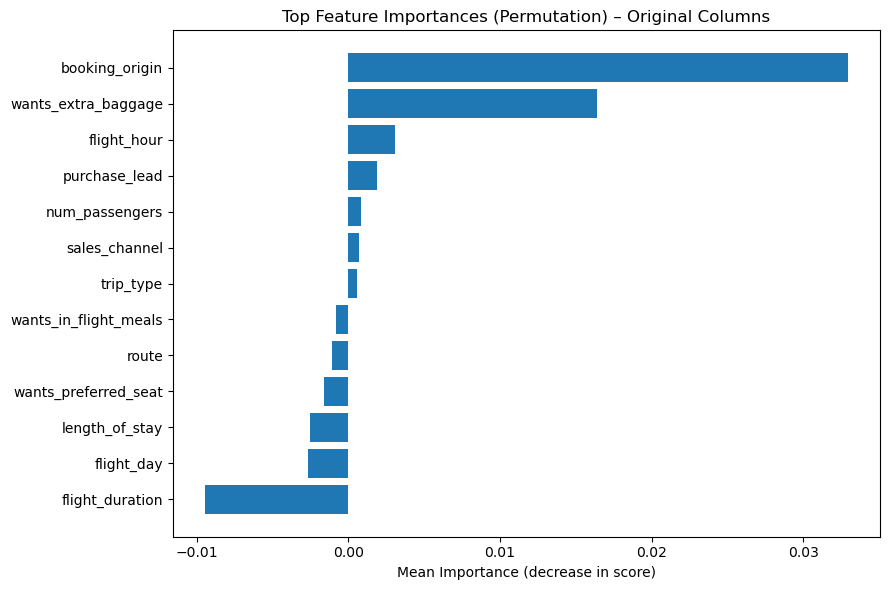

Saved plot: D:\forage\British airways\feature_importance.png


In [5]:
# --- FIX: Permutation importance on original columns (pre-OHE) ---
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Rebuild X, y in case you ran cells out of order
exclude = {"made_booking","id","booking_id","customer_id"}
features = [c for c in df_eng.columns if c not in exclude]
X = df_eng[features]
y = df_eng["made_booking"].astype(int)

# Fit the best estimator on a train/holdout split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=7)
best_est.fit(Xtr, ytr)

# Permutation importance on the Pipeline = importances for ORIGINAL columns
feat_names = features  # <-- key change
perm = permutation_importance(best_est, Xte, yte, n_repeats=6, random_state=42, n_jobs=-1)

imp = pd.DataFrame({
    "feature": feat_names,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False).head(20)

display(imp)

plt.figure(figsize=(9,6))
plt.barh(imp["feature"][::-1], imp["importance"][::-1])
plt.title("Top Feature Importances (Permutation) – Original Columns")
plt.xlabel("Mean Importance (decrease in score)")
plt.tight_layout()
plot_path = DATA_PATH.parent / "feature_importance.png"
plt.savefig(plot_path, dpi=200)
plt.show()
print("Saved plot:", plot_path)



In [6]:
from pptx import Presentation
from pptx.util import Inches, Pt

prs = Presentation()
sl = prs.slides.add_slide(prs.slide_layouts[5])
sl.shapes.title.text = "Booking Prediction – Model Summary"

tb = sl.shapes.add_textbox(Inches(0.5), Inches(1.2), Inches(5.2), Inches(3.8)).text_frame
tb.word_wrap = True

# Reuse the mean metrics you printed earlier, or compute quickly:
# (if 'metrics' var still exists in your session, feel free to use that)
lines = [
    f"Dataset: {DATA_PATH.name} (enc: {used_encoding}, sep: '{used_sep}')",
    f"Rows used: {len(df_eng):,} | Features: {len(features)} | Target rate: {y.mean():.2f}",
    f"Eval: {n_splits}-fold CV",
    f"ROC AUC ≈ {m['ROC_AUC']:.3f} | Acc {m['Accuracy']:.3f} | Prec {m['Precision']:.3f} | Rec {m['Recall']:.3f} | F1 {m['F1']:.3f}",
    "",
    "Permutation importance shown for original input columns."
]
p0 = tb.paragraphs[0]; p0.text = lines[0]
for line in lines[1:]:
    r = p0.add_run(); r.text = "\n" + line
for para in tb.paragraphs: para.font.size = Pt(14)

sl.shapes.add_picture(str(plot_path), Inches(6.0), Inches(1.2), height=Inches(4.2))
ppt_path = DATA_PATH.parent / "Booking_Model_Summary.pptx"
prs.save(ppt_path)
print("Saved PPT:", ppt_path)


Saved PPT: D:\forage\British airways\Booking_Model_Summary.pptx
